# 🍷 Wine Quality Prediction — Complete ML Project
**Dataset:** Red Wine Quality | **Task:** Binary Classification (GOOD vs BAD)

---

## STEP 1: Import Libraries

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## STEP 2: Load Dataset & Basic EDA

In [4]:
# Upload winequality.csv to Colab first, then run this
df = pd.read_csv('winequality.csv')

print('=== SHAPE ===')
print(df.shape)

print('\n=== FIRST 5 ROWS (head) ===')
df.head()

=== SHAPE ===
(1599, 12)

=== FIRST 5 ROWS (head) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
print('=== DATASET INFO (info) ===')
df.info()

=== DATASET INFO (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
print('=== STATISTICAL SUMMARY (describe) ===')
df.describe()

=== STATISTICAL SUMMARY (describe) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## STEP 3: Check Missing Values

In [7]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== MISSING VALUES ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


## STEP 4: Quality Distribution & Correlation Analysis

=== QUALITY VALUE COUNTS ===
3     10
4     53
5    681
6    638
7    199
8     18
Name: quality, dtype: int64


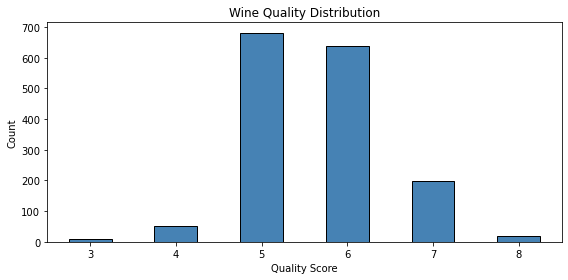

In [8]:
# Quality distribution
print('=== QUALITY VALUE COUNTS ===')
print(df['quality'].value_counts().sort_index())

# Plot quality distribution
plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

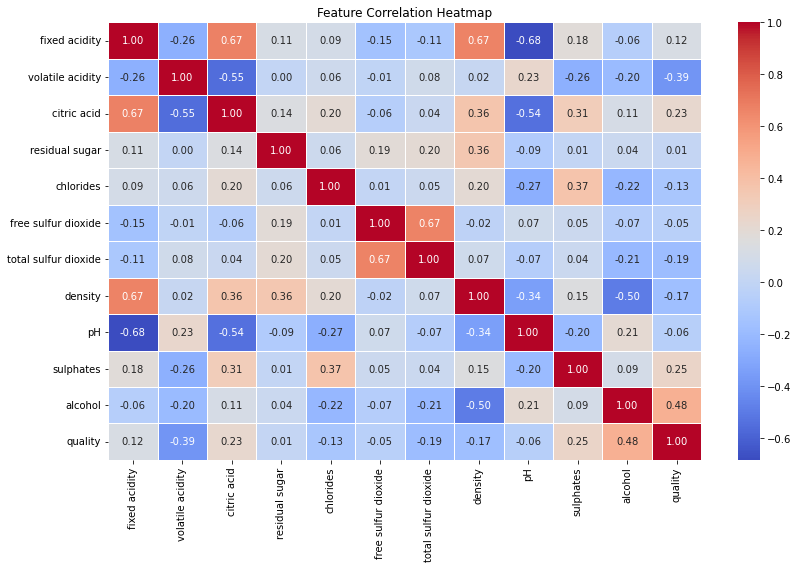


=== CORRELATION WITH QUALITY ===
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Correlation with quality column specifically
print('\n=== CORRELATION WITH QUALITY ===')
print(df.corr()['quality'].sort_values(ascending=False))

## STEP 5: Create Binary Target — quality_label

=== BINARY LABEL DISTRIBUTION ===
0    1382
1     217
Name: quality_label, dtype: int64

GOOD wines (1): 217
BAD wines (0):  1382


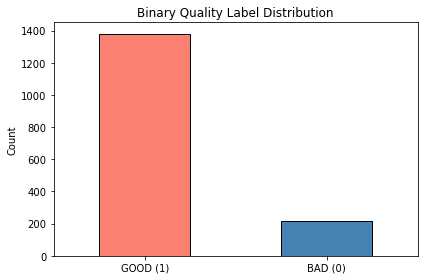

In [10]:
# Create binary label: 1 = GOOD (quality >= 7), 0 = BAD (quality < 7)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print('=== BINARY LABEL DISTRIBUTION ===')
print(df['quality_label'].value_counts())
print(f'\nGOOD wines (1): {df["quality_label"].sum()}')
print(f'BAD wines (0):  {len(df) - df["quality_label"].sum()}')

# Visualize
plt.figure(figsize=(6, 4))
df['quality_label'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['GOOD (1)', 'BAD (0)'], rotation=0)
plt.title('Binary Quality Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## STEP 6: Feature-Target Split & Train-Test Split

In [11]:
# X = all features EXCEPT original quality & our new label
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

print('Feature matrix shape (X):', X.shape)
print('Target vector shape (y): ', y.shape)
print('\nFeatures used:', list(X.columns))

Feature matrix shape (X): (1599, 11)
Target vector shape (y):  (1599,)

Features used: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [12]:
# 80% train, 20% test — random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:  ', X_train.shape[0])
print('Testing set size:   ', X_test.shape[0])
print('Train class balance:', y_train.value_counts().to_dict())
print('Test class balance: ', y_test.value_counts().to_dict())

Training set size:   1279
Testing set size:    320
Train class balance: {0: 1109, 1: 170}
Test class balance:  {0: 273, 1: 47}


## STEP 7: Logistic Regression — WITHOUT Scaling

In [13]:
# Helper function to print all evaluation metrics
def evaluate_model(y_test, y_pred, model_name='Model'):
    print(f'\n========== {model_name} ==========')
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['BAD (0)', 'GOOD (1)']))
    print('Confusion Matrix:')
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['BAD', 'GOOD'],
                yticklabels=['BAD', 'GOOD'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return accuracy_score(y_test, y_pred)


========== Logistic Regression (No Scaling) ==========
Accuracy : 0.8594
Precision: 0.5500
Recall   : 0.2340
F1-Score : 0.3284

Classification Report:
              precision    recall  f1-score   support

     BAD (0)       0.88      0.97      0.92       273
    GOOD (1)       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320

Confusion Matrix:
[[264   9]
 [ 36  11]]


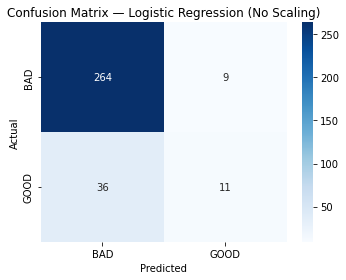

In [14]:
# Logistic Regression WITHOUT scaling
lr_no_scale = LogisticRegression(random_state=42, max_iter=1000)
lr_no_scale.fit(X_train, y_train)
y_pred_lr_no = lr_no_scale.predict(X_test)

acc_no_scale = evaluate_model(y_test, y_pred_lr_no, 'Logistic Regression (No Scaling)')

## STEP 8: Apply StandardScaler & Logistic Regression WITH Scaling

In [ ]:
# StandardScaler: transforms data to mean=0, std=1
scaler = StandardScaler()

# IMPORTANT: fit only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Before scaling — mean of first feature:', round(X_train.iloc[:, 0].mean(), 4))
print('After scaling  — mean of first feature:', round(X_train_scaled[:, 0].mean(), 4))
print('After scaling  — std of first feature: ', round(X_train_scaled[:, 0].std(), 4))

AttributeError: 'float' object has no attribute 'round'


========== Logistic Regression (With Scaling) ==========
Accuracy : 0.8656
Precision: 0.5909
Recall   : 0.2766
F1-Score : 0.3768

Classification Report:
              precision    recall  f1-score   support

     BAD (0)       0.89      0.97      0.92       273
    GOOD (1)       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320

Confusion Matrix:
[[264   9]
 [ 34  13]]


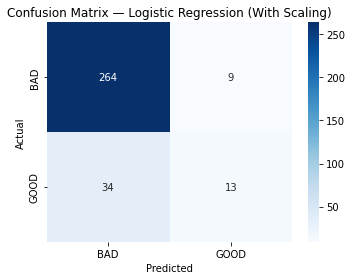

In [18]:
# Logistic Regression WITH scaling
lr_scaled = LogisticRegression(random_state=42, max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr_sc = lr_scaled.predict(X_test_scaled)

acc_scaled = evaluate_model(y_test, y_pred_lr_sc, 'Logistic Regression (With Scaling)')

In [17]:
# Compare before vs after scaling
print('=== SCALING COMPARISON ===')
print(f'Without Scaling — Accuracy: {acc_no_scale:.4f}')
print(f'With Scaling    — Accuracy: {acc_scaled:.4f}')
improvement = (acc_scaled - acc_no_scale) * 100
print(f'Improvement: {improvement:+.2f}%')

=== SCALING COMPARISON ===
Without Scaling — Accuracy: 0.8594


NameError: name 'acc_scaled' is not defined

## STEP 9: Compare 3 Models — LR, KNN, Decision Tree

In [16]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4)
    }

results_df = pd.DataFrame(results).T
print('=== MODEL COMPARISON TABLE ===')
print(results_df)

best_model_name = results_df['F1-Score'].idxmax()
print(f'\n>>> BEST MODEL by F1-Score: {best_model_name} ({results_df.loc[best_model_name, "F1-Score"]})')

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8656     0.5909  0.2766    0.3768
KNN (k=5)              0.8812     0.6452  0.4255    0.5128
Decision Tree          0.8719     0.5714  0.5106    0.5393

>>> BEST MODEL by F1-Score: Decision Tree (0.5393)


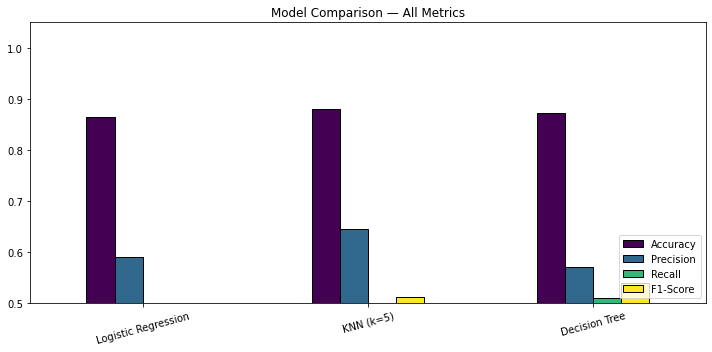

In [19]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 5), colormap='viridis', edgecolor='black')
plt.title('Model Comparison — All Metrics')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## STEP 10: Hyperparameter Tuning with GridSearchCV

In [20]:
# Tuning Decision Tree (commonly the best on this dataset)
# Adjust model name if your best model was different

param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV F1-Score:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1-Score: 0.5565



========== Decision Tree (After GridSearchCV Tuning) ==========
Accuracy : 0.8781
Precision: 0.5909
Recall   : 0.5532
F1-Score : 0.5714

Classification Report:
              precision    recall  f1-score   support

     BAD (0)       0.92      0.93      0.93       273
    GOOD (1)       0.59      0.55      0.57        47

    accuracy                           0.88       320
   macro avg       0.76      0.74      0.75       320
weighted avg       0.88      0.88      0.88       320

Confusion Matrix:
[[255  18]
 [ 21  26]]


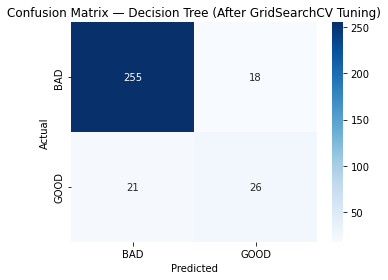

0.878125

In [21]:
# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

evaluate_model(y_test, y_pred_tuned, 'Decision Tree (After GridSearchCV Tuning)')

## STEP 11: Feature Importance Analysis

=== FEATURE IMPORTANCE (Decision Tree) ===
alcohol                  : 0.2481  ████████████
sulphates                : 0.1919  █████████
total sulfur dioxide     : 0.1380  ██████
pH                       : 0.0816  ████
free sulfur dioxide      : 0.0748  ███
volatile acidity         : 0.0603  ███
residual sugar           : 0.0500  ██
chlorides                : 0.0493  ██
citric acid              : 0.0402  ██
fixed acidity            : 0.0362  █
density                  : 0.0296  █


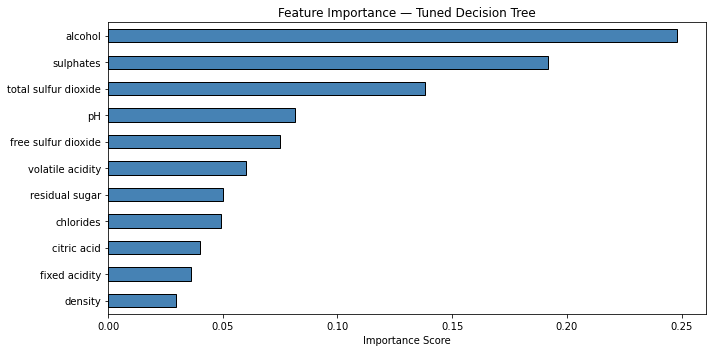

In [22]:
# Feature importance from Decision Tree
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('=== FEATURE IMPORTANCE (Decision Tree) ===')
for feat, imp in feature_importance.items():
    bar = '█' * int(imp * 50)
    print(f'{feat:25s}: {imp:.4f}  {bar}')

# Bar chart
plt.figure(figsize=(10, 5))
feature_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Tuned Decision Tree')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Bonus: Logistic Regression coefficients as feature importance
lr_coef = pd.Series(
    np.abs(lr_scaled.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print('=== FEATURE IMPORTANCE (Logistic Regression — absolute coefficients) ===')
print(lr_coef.round(4))

=== FEATURE IMPORTANCE (Logistic Regression — absolute coefficients) ===
alcohol                 0.8089
total sulfur dioxide    0.5966
sulphates               0.5801
volatile acidity        0.4882
fixed acidity           0.4425
density                 0.4420
chlorides               0.3281
residual sugar          0.3107
free sulfur dioxide     0.1222
citric acid             0.0704
pH                      0.0362
dtype: float64


## STEP 12: Final Summary

In [24]:
print('=' * 55)
print('       WINE QUALITY ML PROJECT — FINAL SUMMARY')
print('=' * 55)
print(f'Dataset: {df.shape[0]} rows, {X.shape[1]} features')
print(f'Target: Binary — GOOD (1) vs BAD (0)')
print(f'GOOD wines: {y.sum()} | BAD wines: {len(y)-y.sum()}')
print()
print('--- Model Results (on scaled data) ---')
print(results_df.to_string())
print()
print(f'Best model: {best_model_name}')
print(f'After GridSearchCV tuning:')
print(f'  F1-Score  = {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  Accuracy  = {accuracy_score(y_test, y_pred_tuned):.4f}')
print()
print('Top 3 Important Features:')
for i, (feat, val) in enumerate(feature_importance.head(3).items(), 1):
    print(f'  {i}. {feat} ({val:.4f})')
print('=' * 55)

       WINE QUALITY ML PROJECT — FINAL SUMMARY
Dataset: 1599 rows, 11 features
Target: Binary — GOOD (1) vs BAD (0)
GOOD wines: 217 | BAD wines: 1382

--- Model Results (on scaled data) ---
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8656     0.5909  0.2766    0.3768
KNN (k=5)              0.8812     0.6452  0.4255    0.5128
Decision Tree          0.8719     0.5714  0.5106    0.5393

Best model: Decision Tree
After GridSearchCV tuning:
  F1-Score  = 0.5714
  Accuracy  = 0.8781

Top 3 Important Features:
  1. alcohol (0.2481)
  2. sulphates (0.1919)
  3. total sulfur dioxide (0.1380)
